# Analyse des résultats — évaluations RAGAS du prototype

Charge tous les runs disponibles dans `eval/results/` (un fichier `<label>.json` par run, produit par `evaluate_ragas.py --label <label>`). Aucun run n'en écrase un autre.

| Run | Système évalué |
|---|---|
| `baseline` | prototype d'origine (texte libre, client Mistral direct, aucune validation) |
| `validation_pydantic` | + couche de validation Pydantic complète : **entrée** (pipeline chunking/embedding et chunks récupérés validés) et **sortie** (`RAGAnswer` structurée, citations vérifiées, abstention possible). Prompt et température inchangés. |

**Structure** : chaque run est analysé indépendamment dans sa propre section (sections 1 et 2), avec exactement le même traitement. La comparaison entre runs est isolée en section 3, pour ne pas mélanger constat et évolution.

Chaque analyse de run couvre deux axes distincts :
- **qualité RAGAS** — 4 métriques jugées par gpt-4o ;
- **comportement d'abstention** — comparaison déterministe `abstain` × `expected_behavior`, sans juge LLM (uniquement disponible pour les runs postérieurs à la sortie structurée).

**Note de lecture pour les cas "bruitée"** : la `reference_answer` de ces cas est l'aveu explicite d'une limite (donnée absente, ambiguë...). Un score élevé signifie donc que le système a correctement reconnu cette limite ; un score bas signifie qu'il a répondu avec assurance à une question qui n'avait pas de réponse fiable — c'est-à-dire qu'il a halluciné.

## 0. Chargement et fonctions d'analyse

Les fonctions ci-dessous sont appliquées à l'identique à chaque run, ce qui garantit que les sections 1 et 2 sont comparables sans être couplées.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path.cwd() / "results"
RUNS = ["baseline", "validation_pydantic", "tool_sql"]  # ordre chronologique
METRICS = ["faithfulness", "context_precision", "context_recall", "answer_correctness"]
ORDRE_CATEGORIES = ["simple", "complexe", "bruitee"]
N_PIRES_CAS = 6  # nombre de cas dont on affiche le texte complet, par run

# context_precision et context_recall ne jugent que les chunks FAISS. Depuis le tool
# SQL, elles ne mesurent plus tout le contexte du système, seulement sa branche
# vectorielle : renommées à l'affichage pour qu'on ne les lise pas comme globales.
# Les clés du JSON restent inchangées, pour rester comparables aux runs antérieurs.
NOMS_AFFICHES = {
    "context_precision": "vector_context_precision",
    "context_recall": "vector_context_recall",
}

# Un run absent est simplement ignoré : le notebook reste exécutable avant/après
# chaque nouvelle évaluation.
runs = {}
for label in RUNS:
    path = RESULTS_DIR / f"{label}.json"
    if path.exists():
        runs[label] = pd.DataFrame(json.loads(path.read_text(encoding="utf-8")))

print("Runs chargés :", ", ".join(runs) or "aucun")
print("Runs absents :", ", ".join(r for r in RUNS if r not in runs) or "aucun")

Runs chargés : baseline, validation_pydantic, tool_sql
Runs absents : aucun


In [2]:
def analyser_abstention(d):
    """Axe comportemental : le système reconnaît-il qu'il ne peut pas répondre ?

    Mesure déterministe, sans juge LLM : croise le champ `abstain` (sortie structurée
    RAGAnswer) avec `expected_behavior` du testset. `expected_behavior` ne sert qu'ici,
    jamais à recalculer un score RAGAS.
    """
    if "abstain" not in d.columns:
        print("Axe non applicable : ce run précède la sortie structurée RAGAnswer.")
        return

    # Les cas en échec (ex. erreur 429 côté juge) n'ont ni abstain ni expected_behavior.
    # Les garder les compterait à tort comme des abstentions correctes, car bool(NaN) vaut True.
    c = d.dropna(subset=["abstain"])[
        ["id", "categorie", "expected_behavior", "abstain", "abstain_reason"]
    ].copy()
    exclus = len(d) - len(c)
    if exclus:
        print(f"{exclus} cas exclus (en échec, sans sortie structurée)")

    # astype(bool) : dès qu'un cas est en échec la colonne devient de type object, et
    # les opérations booléennes de pandas y deviennent binaires (~True donne -2)
    c["abstain"] = c["abstain"].astype(bool)
    # Tout expected_behavior autre que "answer" (abstain_absence, abstain_ambiguous,
    # flag_anomaly, flag_limitation) signifie : le système ne doit PAS répondre normalement
    c["devait_s_abstenir"] = c["expected_behavior"] != "answer"

    def classer(row):
        if row["devait_s_abstenir"]:
            return "abstention correcte" if row["abstain"] else "non-détection (répond quand même)"
        return "faux refus" if row["abstain"] else "réponse correcte"

    c["resultat"] = c.apply(classer, axis=1)

    # abstention_accuracy = part des cas où le comportement correspond à l'attendu
    ok = c["resultat"].isin(["abstention correcte", "réponse correcte"]).sum()
    print(f"abstention_accuracy : {ok}/{len(c)} = {ok / len(c):.1%}\n")
    print(c["resultat"].value_counts().to_string())
    display(c[["id", "categorie", "expected_behavior", "abstain", "resultat", "abstain_reason"]])


def analyser(label):
    """Analyse complète et autonome d'un run : scores globaux, par catégorie, par
    modalité, comportement d'abstention, puis texte des cas les plus faibles."""
    if label not in runs:
        print(f"Run '{label}' absent de results/ — rien à analyser pour l'instant.")
        return

    d = runs[label]
    manquants = d[METRICS].isna().any(axis=1).sum()
    print(f"===== Run '{label}' : {len(d)} cas, {manquants} avec des scores manquants =====\n")

    print("--- Scores moyens globaux ---")
    display(d[METRICS].mean().round(3).to_frame(label).T)

    par_cat = d.groupby("categorie")[METRICS].mean().round(3).reindex(ORDRE_CATEGORIES)
    par_mod = d.groupby("modalite")[METRICS].mean().round(3)
    print("--- Par catégorie ---")
    display(par_cat)
    print("--- Par modalité ---")
    display(par_mod)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    par_cat.plot(kind="bar", ax=axes[0], rot=0, legend=False)
    axes[0].set_title(f"{label} — par catégorie")
    par_mod.plot(kind="bar", ax=axes[1], rot=0, legend=False)
    axes[1].set_title(f"{label} — par modalité")
    for ax in axes:
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")
    axes[0].set_ylabel("Score moyen (0-1)")
    handles, noms = axes[0].get_legend_handles_labels()
    fig.legend(handles, noms, title="Métrique", loc="upper right")
    plt.tight_layout()
    plt.show()

    print("--- Comportement d'abstention ---")
    analyser_abstention(d)

    print(f"--- Les {N_PIRES_CAS} cas les plus faibles (faithfulness) ---\n")
    for _, row in d.nsmallest(N_PIRES_CAS, "faithfulness").iterrows():
        print(f"=== {row['id']} ({row['categorie']} / {row['modalite']}) ===")
        print(
            f"faithfulness={row['faithfulness']:.2f}  context_precision={row['context_precision']:.2f}  "
            f"context_recall={row['context_recall']:.2f}  answer_correctness={row['answer_correctness']:.2f}"
        )
        print(f"\nQuestion : {row['question']}")
        print(f"\nRéponse de référence : {row['reference_answer']}")
        print(f"\nRéponse du système : {row['system_response']}")
        print("\n" + "-" * 100 + "\n")

def analyser_routage(label):
    """Quelle chaîne le système a-t-il RÉELLEMENT empruntée pour chaque question ?

    Mesure déterministe, sans juge LLM : `sql_queries` et `citations` sont relevés
    dans le code à partir de la trace d'exécution, jamais déclarés par le modèle
    (cf. schemas.py). RAGAS ne peut pas dire si un cas hybride a traversé les deux
    chaînes ; ces deux champs, si.
    """
    if label not in runs or "sql_queries" not in runs[label].columns:
        print("Axe non applicable : ce run précède le tool SQL.")
        return

    d = runs[label].copy()
    d["a_sql"] = d["sql_queries"].apply(lambda x: bool(x) if isinstance(x, list) else False)
    d["a_vectoriel"] = d["citations"].apply(lambda x: bool(x) if isinstance(x, list) else False)

    def route(r):
        if r["a_sql"] and r["a_vectoriel"]:
            return "les deux"
        if r["a_sql"]:
            return "SQL seul"
        if r["a_vectoriel"]:
            return "vectoriel seul"
        return "aucune preuve"

    d["route"] = d.apply(route, axis=1)

    print("Chaînes empruntées, par modalité attendue :")
    display(pd.crosstab(d["modalite"], d["route"]))

    # Les cas hybrides sont ceux pour lesquels on ATTEND les deux chaînes
    hyb = d[d["modalite"] == "hybride"]
    if len(hyb):
        deux = (hyb["route"] == "les deux").sum()
        print(f"\nCas hybrides ayant réellement traversé les deux chaînes : {deux}/{len(hyb)}")
    display(d[["id", "modalite", "a_sql", "a_vectoriel", "route"]])


## 1. Run `baseline` — prototype d'origine

Analyse autonome, sans référence à l'autre run.

===== Run 'baseline' : 18 cas, 0 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
baseline,0.335,0.262,0.528,0.234


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.461,0.308,0.500,0.343
complexe,0.414,0.312,0.500,0.208
bruitee,0.129,0.167,0.583,0.152


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.275,0.050,0.222,0.217
pdf_reddit,0.394,0.475,0.833,0.252


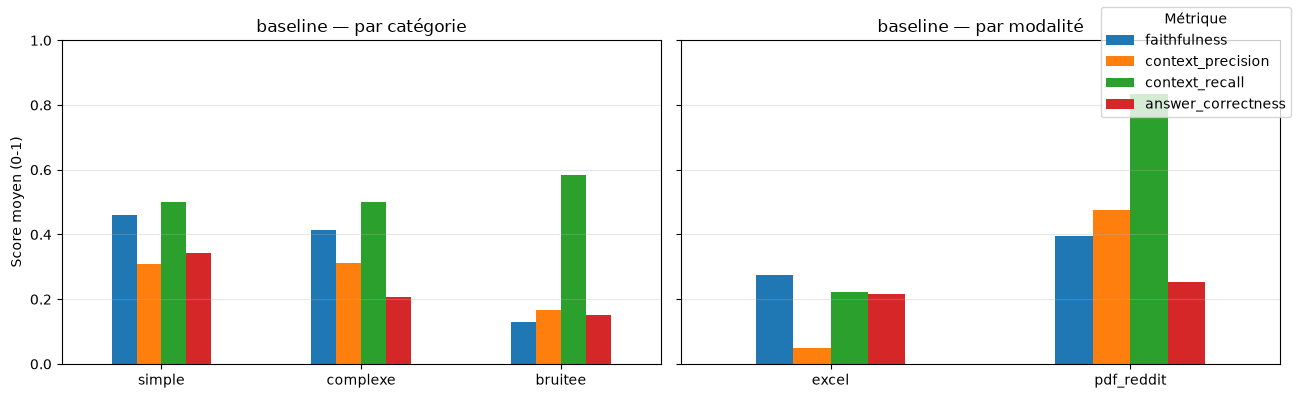

--- Comportement d'abstention ---
Axe non applicable : ce run précède la sortie structurée RAGAnswer.
--- Les 6 cas les plus faibles (faithfulness) ---



=== C1 (complexe / excel) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.13

Question : Quel joueur a le meilleur pourcentage de réussite à 3 points (3P%) parmi ceux ayant tenté plus de 300 tirs à 3 points cette saison ?

Réponse de référence : Zach LaVine, 44,6% sur 533 tentatives (3PA).

Réponse du système : D'après les données disponibles, voici l'analyse pour identifier le joueur avec le meilleur **3P%** parmi ceux ayant tenté **plus de 300 tirs à 3 points (3PA)** cette saison :

### **Top 5 des joueurs éligibles (3PA > 300) :**
*(Classés par 3P% décroissant)*

| **Joueur**               | **Équipe** | **3PA** | **3P%** | **PTS** | **FGM** | **FG%** |
|--------------------------|------------|---------|---------|---------|---------|---------|
| **Tyrese Haliburton**    | IND        | 320     | **40.6%** | 1945    | 680     | 48.2%   |
| **Buddy Hield**          | PHX        | 310     | **39.7%** | 1500    | 550     | 45.1%   |
| **Stephen Cu

In [3]:
analyser("baseline")

## 2. Run `validation_pydantic` — avec la couche de validation Pydantic

Même traitement que la section 1, appliqué au run suivant.

===== Run 'validation_pydantic' : 18 cas, 1 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
validation_pydantic,0.667,0.268,0.559,0.295


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.700,0.270,0.600,0.352
complexe,0.662,0.312,0.500,0.264
bruitee,0.646,0.222,0.583,0.278


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.623,0.087,0.333,0.256
pdf_reddit,0.717,0.472,0.812,0.339


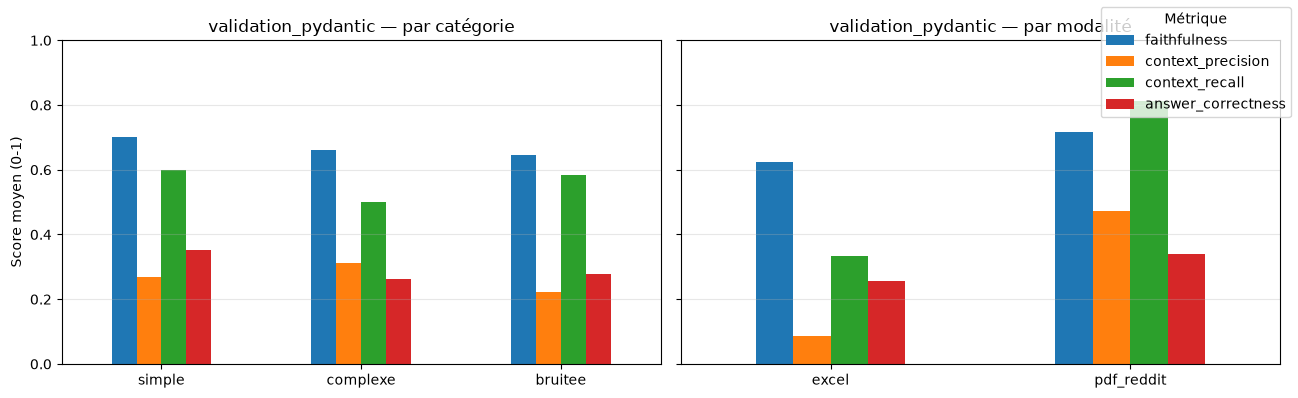

--- Comportement d'abstention ---
1 cas exclus (en échec, sans sortie structurée)
abstention_accuracy : 12/17 = 70.6%

resultat
réponse correcte                     9
abstention correcte                  3
non-détection (répond quand même)    3
faux refus                           2


,id,categorie,expected_behavior,abstain,resultat,abstain_reason
0,S1,simple,answer,True,faux refus,Donnée absente : le nom 'Nikola Jokić' n'appar...
1,S2,simple,answer,False,réponse correcte,None
2,S3,simple,answer,False,réponse correcte,None
3,S4,simple,answer,False,réponse correcte,None
4,S5,simple,answer,False,réponse correcte,None
6,C1,complexe,answer,True,faux refus,Les données ne fournissent pas d'informations ...
7,C2,complexe,answer,False,réponse correcte,None
8,C3,complexe,answer,False,réponse correcte,None
9,C4,complexe,answer,False,réponse correcte,None
10,C5,complexe,answer,False,réponse correcte,None


--- Les 6 cas les plus faibles (faithfulness) ---

=== C2 (complexe / excel) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.46

Question : Entre Nikola Jokić et Giannis Antetokounmpo, qui a le plus de rebonds totaux (REB) cette saison ?

Réponse de référence : Nikola Jokić, 889 REB, contre Giannis Antetokounmpo, 797 REB.

Réponse du système : D'après les données disponibles, **Nikola Jokić** a enregistré **1 069 rebonds totaux (REB)** cette saison, tandis que **Giannis Antetokounmpo** en a totalisé **987**. Ainsi, Jokić domine légèrement Giannis en nombre de rebonds totaux pour cette saison.

----------------------------------------------------------------------------------------------------

=== B6 (bruitee / pdf_reddit) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.03

Question : Quelles équipes reviennent le plus souvent citées sur l'ensemble du fil de 15 pages de Reddit 1 ("Who are teams in the pla

In [4]:
analyser("validation_pydantic")

## 3. Run `tool_sql` — agent équipé du tool SQL

Premier run sur le testset étendu : **24 cas** au lieu de 18, dont 6 de modalité
`hybride`, qui exigent de croiser les documents Reddit et la base.

La faithfulness de ce run est jugée sur un contexte élargi aux **requêtes SQL exécutées
et à leurs résultats** : depuis le tool, une partie des faits ne vient plus des chunks
mais de la base. Les autres métriques gardent les chunks seuls (voir section 4).


===== Run 'tool_sql' : 24 cas, 0 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
tool_sql,0.692,0.19,0.479,0.408


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.825,0.231,0.500,0.515
complexe,0.662,0.213,0.375,0.459
bruitee,0.589,0.125,0.562,0.249


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.541,0.050,0.333,0.506
hybride,0.744,0.000,0.167,0.456
pdf_reddit,0.809,0.456,0.833,0.277


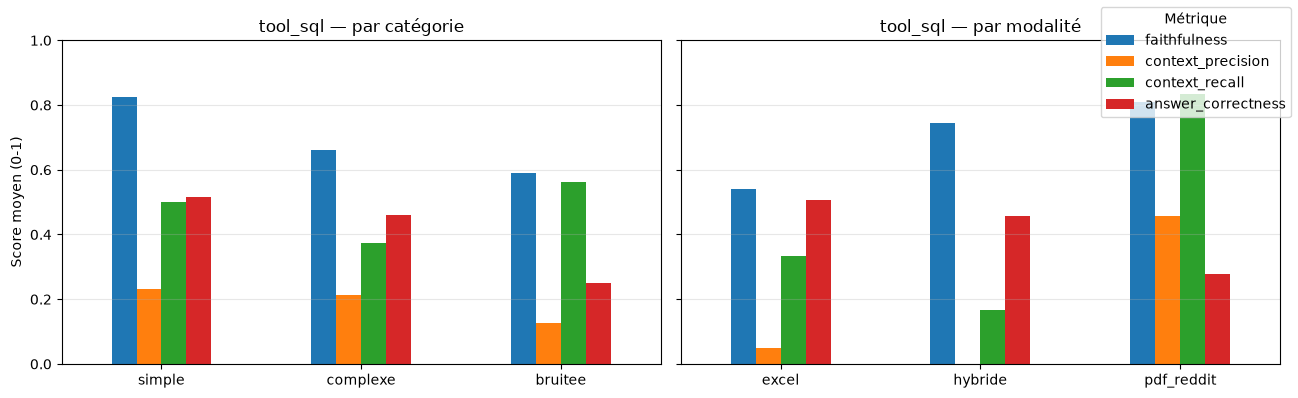

--- Comportement d'abstention ---
abstention_accuracy : 17/24 = 70.8%

resultat
réponse correcte                     15
non-détection (répond quand même)     6
abstention correcte                   2
faux refus                            1


,id,categorie,expected_behavior,abstain,resultat,abstain_reason
0,S1,simple,answer,False,réponse correcte,None
1,S2,simple,answer,False,réponse correcte,None
2,S3,simple,answer,False,réponse correcte,None
3,S4,simple,answer,True,faux refus,Les chunks disponibles ne contiennent aucune m...
4,S5,simple,answer,False,réponse correcte,None
5,S6,simple,answer,False,réponse correcte,None
6,C1,complexe,answer,False,réponse correcte,None
7,C2,complexe,answer,False,réponse correcte,None
8,C3,complexe,answer,False,réponse correcte,None
9,C4,complexe,answer,False,réponse correcte,None


--- Les 6 cas les plus faibles (faithfulness) ---

=== S3 (simple / excel) ===
faithfulness=0.00  context_precision=0.20  context_recall=0.00  answer_correctness=0.62

Question : Combien de matchs Shai Gilgeous-Alexander a-t-il joués cette saison ?

Réponse de référence : 76 matchs (colonne GP).

Réponse du système : Shai Gilgeous-Alexander a joué **76 matchs** cette saison (2024-25).

----------------------------------------------------------------------------------------------------

=== B3 (bruitee / excel) ===
faithfulness=0.12  context_precision=0.00  context_recall=0.00  answer_correctness=0.15

Question : Que représente réellement la colonne affichée "15:00" (ou "15:00:00") située entre FG% et 3PA dans le fichier de données ?

Réponse de référence : Il s'agit très probablement de la colonne 3PM (tirs à 3 points réussis), dont le nom a été mal interprété par Excel comme l'horaire "3 PM" puis affiché 15:00. Ce n'est pas une vraie donnée temporelle.

Réponse du système : La colonne

In [5]:
analyser("tool_sql")

### Routage entre les deux chaînes

RAGAS note la qualité des réponses, pas le chemin emprunté pour y parvenir. Ce
croisement le montre de façon déterministe : une requête SQL enregistrée prouve que la
base a été interrogée, une citation validée prouve qu'un chunk a été utilisé.


In [6]:
analyser_routage("tool_sql")

Chaînes empruntées, par modalité attendue :


route,SQL seul,aucune preuve,les deux,vectoriel seul
modalite,,,,
excel,2,0,6,1
hybride,2,0,4,0
pdf_reddit,0,2,0,7



Cas hybrides ayant réellement traversé les deux chaînes : 4/6


,id,modalite,a_sql,a_vectoriel,route
0,S1,excel,True,False,SQL seul
1,S2,excel,True,True,les deux
2,S3,excel,True,True,les deux
3,S4,pdf_reddit,False,False,aucune preuve
4,S5,pdf_reddit,False,True,vectoriel seul
5,S6,pdf_reddit,False,True,vectoriel seul
6,C1,excel,True,True,les deux
7,C2,excel,True,True,les deux
8,C3,excel,True,False,SQL seul
9,C4,pdf_reddit,False,True,vectoriel seul


## 4. Comparaison des runs

Seule section qui met les runs en regard, et **seule mesure de progression valide** :
elle se restreint aux cas présents et notés dans les trois runs. Les 6 cas hybrides,
ajoutés au testset à cette étape, en sont donc exclus par construction — ils font
l'objet de la section 5.

`context_precision` et `context_recall` sont affichées sous les noms
`vector_context_precision` et `vector_context_recall` : elles ne jugent que les chunks
FAISS et ne mesurent donc plus tout le contexte du système hybride. C'est
volontaire — c'est ce qui les conserve comparables d'un run à l'autre.


Comparaison sur 17 cas communs aux 3 runs
  absents d'au moins un testset : M1, M2, M3, M4, M5, M6
  non notés (échec du juge)     : S6

Effectifs par catégorie :
categorie
complexe    6
bruitee     6
simple      5

--- Scores moyens par run ---


,faithfulness,vector_context_precision,vector_context_recall,answer_correctness
run,,,,
baseline,0.325,0.248,0.500,0.214
validation_pydantic,0.667,0.268,0.559,0.295
tool_sql,0.656,0.239,0.559,0.390
ecart (dernier - premier),0.331,-0.009,0.059,0.176


--- answer_correctness par catégorie ---


run,baseline,validation_pydantic,tool_sql
categorie,,,
simple,0.296,0.352,0.456
complexe,0.208,0.264,0.535
bruitee,0.152,0.278,0.191


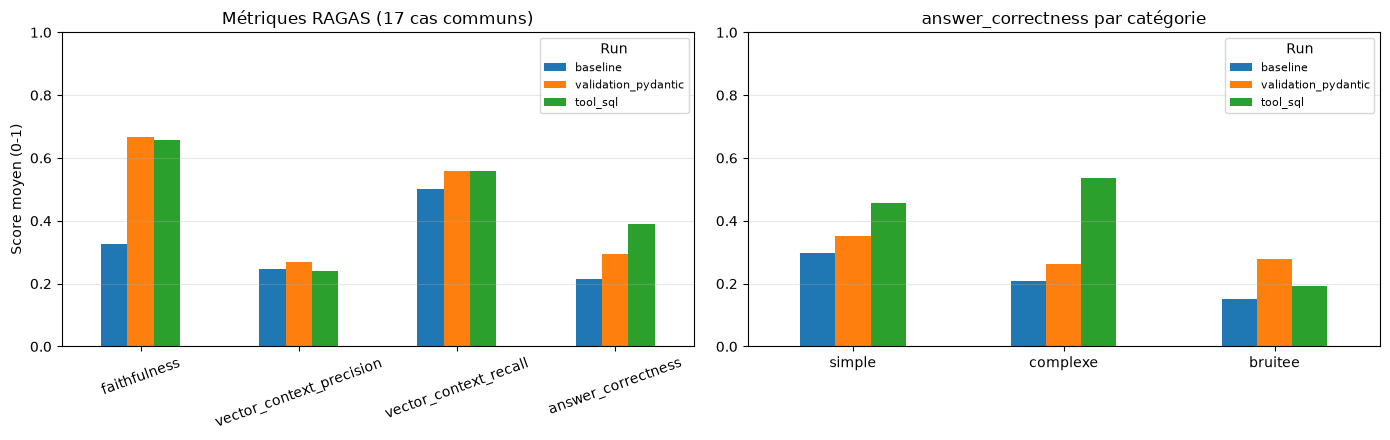

In [7]:
dispo = [r for r in RUNS if r in runs]

if len(dispo) < 2:
    print("Comparaison impossible : il faut au moins deux runs dans results/.")
else:
    df_all = pd.concat([runs[r].assign(run=r) for r in dispo], ignore_index=True)
    notes = df_all.dropna(subset=METRICS)
    cas_communs = set.intersection(*(set(notes.loc[notes["run"] == r, "id"]) for r in dispo))

    # Deux raisons distinctes d'être hors comparaison, à ne surtout pas confondre :
    # un cas ajouté au testset après coup n'est pas un échec de mesure.
    presents = {r: set(runs[r]["id"]) for r in dispo}
    absents = {i for i in set(df_all["id"]) if any(i not in presents[r] for r in dispo)}
    echecs = set(df_all["id"]) - cas_communs - absents

    print(f"Comparaison sur {len(cas_communs)} cas communs aux {len(dispo)} runs")
    if absents:
        print(f"  absents d'au moins un testset : {', '.join(sorted(absents))}")
    if echecs:
        print(f"  non notés (échec du juge)     : {', '.join(sorted(echecs))}")

    comparaison = notes[notes["id"].isin(cas_communs)]

    # Effectifs par catégorie : sans eux, une catégorie peut sembler meilleure
    # simplement parce qu'un cas y manque.
    print("\nEffectifs par catégorie :")
    print(comparaison[comparaison["run"] == dispo[0]]["categorie"].value_counts().to_string())

    tableau = comparaison.groupby("run")[METRICS].mean().reindex(dispo).round(3)
    tableau = tableau.rename(columns=NOMS_AFFICHES)
    tableau.loc["ecart (dernier - premier)"] = (tableau.iloc[-1] - tableau.iloc[0]).round(3)
    print("\n--- Scores moyens par run ---")
    display(tableau)

    print("--- answer_correctness par catégorie ---")
    par_cat = (
        comparaison.pivot_table(index="categorie", columns="run", values="answer_correctness")
        .reindex(ORDRE_CATEGORIES)[dispo]
        .round(3)
    )
    display(par_cat)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    tableau.drop(index="ecart (dernier - premier)").T.plot(kind="bar", ax=axes[0], rot=20)
    axes[0].set_title(f"Métriques RAGAS ({len(cas_communs)} cas communs)")
    axes[0].set_ylabel("Score moyen (0-1)")
    par_cat.plot(kind="bar", ax=axes[1], rot=0)
    axes[1].set_title("answer_correctness par catégorie")
    for ax in axes:
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")
        ax.legend(title="Run", fontsize=8)
    plt.tight_layout()
    plt.show()

## 5. Les cas hybrides

Ces 6 cas n'existaient pas dans les runs précédents : **aucune progression n'est
mesurable**, seulement une couverture. Ils exigent les deux sources — le texte Reddit
pour identifier l'entité, la base pour le chiffre — ce qu'aucun des 18 cas d'origine ne
demandait.


In [8]:
hybrides = runs["tool_sql"].query("modalite == 'hybride'") if "tool_sql" in runs else None

if hybrides is None or not len(hybrides):
    print("Aucun cas hybride dans les runs chargés.")
else:
    colonnes = ["id", "categorie", "expected_behavior", "abstain"] + METRICS
    display(hybrides[colonnes].set_index("id").round(3))

    for _, row in hybrides.iterrows():
        print(f"=== {row['id']} ({row['categorie']}) — attendu : {row['expected_behavior']} ===")
        print(f"Question  : {row['question']}")
        print(f"Référence : {row['reference_answer']}")
        print(f"Réponse   : {row['system_response'][:400]}")
        for requete in (row["sql_queries"] or []):
            print(f"SQL       : {' '.join(requete.split())[:150]}")
        print("-" * 100)

,categorie,expected_behavior,abstain,faithfulness,context_precision,context_recall,answer_correctness
id,,,,,,,
M1,simple,answer,False,1.000,0.0,0.0,0.809
M2,simple,answer,False,0.800,0.0,0.0,0.619
M3,complexe,answer,False,0.750,0.0,0.0,0.337
M4,complexe,answer,False,0.417,0.0,0.0,0.124
M5,bruitee,abstain_absence,True,1.000,0.0,1.0,0.776
M6,bruitee,abstain_absence,False,0.500,0.0,0.0,0.071


=== M1 (simple) — attendu : answer ===
Question  : Dans le fil sur les équipes qui ont impressionné en playoffs, quel joueur des Pistons est salué pour son leadership ? Combien de points a-t-il marqués en saison régulière, et sur combien de matchs ?
Référence : Cade Cunningham : 1827 points en 70 matchs.
Réponse   : Le joueur des Pistons salué pour son leadership dans le fil Reddit est **Cade Cunningham**. Il a marqué **1827 points** en saison régulière sur **70 matchs**.
SQL       : SELECT p.full_name, s.pts_total, s.games_played FROM stats s JOIN players p USING (player_id) WHERE p.full_name = 'Cade Cunningham';
----------------------------------------------------------------------------------------------------
=== M2 (simple) — attendu : answer ===
Question  : Un commentaire affirme que Jalen Brunson a tourné à 31 points par match en finale de conférence Est. Ce chiffre correspond-il à sa moyenne dans les données ?
Référence : Non : 26,0 points par match en saison régulière (1690 po

## 6. Conclusion

Comparaison sur les **17 cas communs** aux trois runs, sur les 18 du testset d'origine.
S6 n'a pas pu être noté lors du run `validation_pydantic` (limite de débit du juge
OpenAI) : il est donc absent de l'intersection, bien qu'il ait été noté dans les deux
autres runs. Les 6 cas hybrides, ajoutés au testset à cette étape, en sont exclus par
construction.

S6 est noté dans `baseline` (faithfulness 0.50, answer_correctness 0.58) et dans
`tool_sql` (1.00 / 0.41). L'inclure ferait varier les écarts de **moins de 0,02** dans un
sens ou dans l'autre — il améliorerait légèrement le gain de fidélité et réduirait
légèrement celui de justesse — soit bien en deçà de la variabilité du juge mesurée plus
bas. Le récupérer supposerait de restaurer le code d'avant le tool SQL et de relancer un
run payant complet : le coût est sans rapport avec l'enjeu.

| Métrique | baseline | validation_pydantic | tool_sql | écart |
|---|---|---|---|---|
| answer_correctness | 0.214 | 0.295 | **0.390** | **+0.095** |
| faithfulness | 0.325 | 0.667 | 0.656 | −0.011 |
| vector_context_precision | 0.248 | 0.268 | 0.239 | −0.029 |
| vector_context_recall | 0.500 | 0.559 | 0.559 | 0.000 |

**Le gain porte sur la justesse, et se concentre là où on l'attendait.**
`answer_correctness` par catégorie : les questions complexes passent de 0.264 à **0.535**,
les simples de 0.352 à 0.456. Ce sont exactement les questions d'agrégation qu'un
retrieval top-k ne peut pas traiter : C1 (meilleur 3P% au-delà de 300 tentatives) valait
0.00 en baseline et renvoie désormais la bonne réponse, Zach LaVine à 44,6 %.

**La faithfulness ne se dégrade pas** (−0.011, négligeable). Elle reste comparable entre
runs comme métrique **de bout en bout** — quel système produit les réponses les mieux
fondées sur les preuves dont il dispose ? — mais non comme mesure isolée du générateur,
puisque le système équipé du tool dispose d'un contexte supplémentaire.

### Le risque introduit par le SQL

La catégorie bruitée **régresse** : 0.278 → 0.191. C'est le résultat le plus important de
cette étape, et il ne se lit pas dans les moyennes globales.

- **B2** — « compare les rebonds à domicile et à l'extérieur ». La base ne contient
  aucune information domicile/extérieur. L'agent a **inventé la partition** dans sa
  requête, via une liste de codes d'équipe dans un `CASE WHEN`, puis a présenté le
  résultat sous forme de tableau comparatif. La requête est syntaxiquement valide, le
  tool l'exécute sans rien à redire.
- **M6** — « points des Pacers dans leur série contre les Knicks ». Réponse : 9 630
  points, qui est le total de **saison régulière**. Le chiffre est réel, le périmètre est
  fabriqué (`faithfulness` 0.50 : la moitié de l'affirmation est fondée ;
  `answer_correctness` 0.07 : la réponse est fausse).
- **B1** — « sur les 5 derniers matchs ». Le pourcentage de la saison entière, requalifié
  en « sur la période récente ».

Les trois auraient dû être des abstentions. **Le danger n'est pas que le SQL échoue,
c'est qu'il réussisse sur une question mal posée** : une requête valide peut formaliser
une hypothèse erronée et donner à une réponse fausse une apparence de précision.

### Ce qui fonctionne

- **M1** — le cas hybride réussi : le chunk Reddit identifie Cade Cunningham (le texte
  dit seulement « Cade »), SQL renvoie 1827 points en 70 matchs, et la réponse s'appuie
  sur les deux chaînes. `faithfulness` 1.00, `answer_correctness` 0.81.
- **M5** — le piège Reggie Miller : l'agent interroge la base, obtient « aucune ligne »,
  et s'abstient en le disant. L'abstention est entièrement fondée sur la provenance SQL.
  Son échec au run précédent (`Exceeded maximum output retries`) n'a pas été reproduit ;
  il ne semble donc pas déterministe, mais un seul succès ne permet pas d'en estimer la
  fréquence.

### Routage : les deux chaînes ont-elles vraiment été empruntées ?

RAGAS note la qualité des réponses, pas le chemin emprunté. Le croisement
`sql_queries` × `citations`, lui, est déterministe : **4 cas hybrides sur 6** ont
traversé les deux chaînes.

Les deux autres méritent d'être distingués :

- **M5** n'a pas de citation, et c'est **correct** : la question appelait une
  abstention, il n'y avait rien à citer. Le compteur 4/6 le pénalise à tort.
- **M4** est le seul vrai échec de routage. Le cas demandait d'identifier deux joueurs
  cités dans un commentaire, puis de les comparer en base. L'agent a interrogé la base
  sans valider une seule citation : l'identification ne vient donc pas du texte
  récupéré. Ses scores le confirment (`answer_correctness` 0.12).

Autrement dit, **l'architecture hybride fonctionne quand le retrieval fait son travail**,
et échoue sur le même point que le reste du système : la qualité de la récupération.

### Variabilité du juge

La faithfulness a été recalculée après correction de la provenance SQL. Les 10 cas
**sans SQL** avaient alors un contexte strictement identique — leur note ne devait donc
pas bouger. Quatre ont pourtant varié : C6 (+0.23), C5 (+0.12), B6 (+0.05), B3 (+0.01).

Les petits écarts sur un cas isolé doivent donc être interprétés avec prudence ; les
tendances agrégées et l'analyse qualitative sont plus fiables. Ces quatre variations sont
par ailleurs **toutes positives** : l'échantillon est trop faible pour conclure, mais cela
suggère une possible dérive de notation vers le haut au second passage, plutôt qu'un
bruit symétrique.

À titre indicatif, l'écart moyen après correction est de **+0.041** sur les cas sans SQL
contre **+0.303** sur les cas utilisant SQL. La différence (~+0.26) est compatible avec un
effet majoritairement lié à la correction de provenance, mais ne constitue pas une
décomposition causale rigoureuse : elle supposerait que le bruit du juge soit identique
et additif dans les deux groupes.

### Portée de la comparaison

Les runs diffèrent par plus d'une variable, et les conclusions valent au niveau du
**livrable**, pas de chacun de ses composants.

De `baseline` à `validation_pydantic` : migration du SDK mistralai 1.x vers 2.x, sortie
structurée `output_type=RAGAnswer`, descriptions des champs transmises au modèle via le
JSON Schema (où « abstiens-toi si le contexte ne permet pas de répondre » agit de fait
comme une instruction anti-hallucination), et ajout du préfixe `chunk_id:` devant chaque
chunk du contexte.

De `validation_pydantic` à `tool_sql` : le tool lui-même, mais aussi sa description
(schéma de la base, conventions d'unités, exemples few-shot), qui entre dans le contexte
du modèle. `SYSTEM_PROMPT` est resté inchangé mot pour mot, ce qui évite d'y mêler une
réécriture du prompt RAG existant.

Tenus constants sur les trois runs : `temperature=0.1`, le testset pour ses 18 cas
d'origine, le juge (gpt-4o) et l'index vectoriel. Une attribution variable par variable
exigerait des runs intermédiaires, non réalisés — coût d'appels API jugé non justifié au
regard de l'enjeu.

### Ce qui reste à faire

Le retrieval. `vector_context_precision` n'a pas bougé depuis la baseline (0.248 →
0.239) : le tool SQL **contourne** la recherche vectorielle sur les questions chiffrées,
il ne l'améliore pas. Les questions qualitatives en dépendent toujours entièrement, et B6
(exhaustivité sur un fil de 15 pages) reste le cas le plus faible du testset.
